# Dynamic counterfactual: Actual vs. TR93, NPP, BA

Counterfactual paths of the funds rate, inflation and the output gap when the policy equation is replaced by a benchmark rule, holding the estimated transition equations and their structural shocks fixed (Hinterlang & Tänzer 2021, Section 3.3, without the RL policies).

**Environment** (restricted recursive SVAR, eqs. 6-7, OLS equation by equation on 1987Q3-2007Q2):

$$
\begin{aligned}
y_t &= C^y + a^y_{y,1} y_{t-1} + a^y_{\pi,1} \pi_{t-1} + a^y_{i,1} i_{t-1} + a^y_{i,2} i_{t-2} + \varepsilon^y_t \\
\pi_t &= C^\pi + a^\pi_{y,0} y_t + a^\pi_{y,1} y_{t-1} + a^\pi_{y,2} y_{t-2} + a^\pi_{\pi,1} \pi_{t-1} + a^\pi_{\pi,2} \pi_{t-2} + a^\pi_{i,1} i_{t-1} + \varepsilon^\pi_t
\end{aligned}
$$

**Counterfactual recursion.** With $\hat\varepsilon^y_t, \hat\varepsilon^\pi_t$ the residuals of the two equations on actual data, and the first two quarters fixed at their actual values:

$$
\tilde y_t = \hat f^{\,y}(\tilde y_{t-1}, \tilde\pi_{t-1}, \tilde\imath_{t-1}, \tilde\imath_{t-2}) + \hat\varepsilon^y_t, \qquad
\tilde\pi_t = \hat f^{\,\pi}(\tilde y_t, \tilde y_{t-1}, \tilde y_{t-2}, \tilde\pi_{t-1}, \tilde\pi_{t-2}, \tilde\imath_{t-1}) + \hat\varepsilon^\pi_t, \qquad
\tilde\imath_t = \alpha_0 + \beta_\pi \tilde\pi_t + \beta_y \tilde y_t
$$

Feeding the actual funds rate through the same recursion returns the actual data exactly, which is asserted below.

| Rule | $\alpha_0$ | $\beta_\pi$ | $\beta_y$ |
|---|---|---|---|
| TR93 | 1 | 1.5 | 0.5 |
| NPP | 0 | 2.0 | 0.5 |
| BA | 1 | 1.5 | 1.0 |

Data: `GDPDEF` (percent change from a year ago), `GDPC1`/`GDPPOT` (output gap), `FEDFUNDS` (quarterly average), via `fedfred`.

## 1. Configuration

In [1]:
# MIT License
# Copyright (c) 2026 Nikhil Sunder

from __future__ import annotations

import os
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fedfred import FredAPI

SAMPLE_START = "1987-07-01"    # 1987Q3; first two quarters are the initial conditions
SAMPLE_END: str | None = None   # None -> latest available quarter ("2022-10-01" matches the paper figure)
EST_END = "2007-04-01"         # 2007Q2, end of the estimation window

INFLATION = "yoy"              # "yoy": 100*(P_t/P_{t-4} - 1); "qoq_ann": 400*ln(P_t/P_{t-1})
COEFS = "estimated"            # "estimated": OLS on this data vintage; "paper": Table 9 of the paper
R_STAR = 2.0
PI_STAR = 2.0
ZLB = False                    # floor rule prescriptions at zero (the benchmark rules are unconstrained)

FIG_DIR = Path("figs")
FIG_DPI = 200

if INFLATION not in {"yoy", "qoq_ann"}:
    raise ValueError(f"INFLATION must be 'yoy' or 'qoq_ann', got {INFLATION!r}")
if COEFS not in {"estimated", "paper"}:
    raise ValueError(f"COEFS must be 'estimated' or 'paper', got {COEFS!r}")

## 2. Data

In [2]:
fred = FredAPI(api_key="7ab121fb17773e187bb6508e83e411da")

# Pull five extra quarters so the inflation transform is defined at SAMPLE_START.
_fetch_start = (pd.Timestamp(SAMPLE_START) - pd.DateOffset(months=15)).strftime("%Y-%m-%d")


def fetch_quarterly(series_id: str, **kwargs: str) -> pd.Series:
    """Fetch one FRED series as a float Series indexed by quarter-start Timestamp.

    Args:
        series_id: FRED series identifier.
        **kwargs: Extra ``get_series_observations`` arguments (e.g. ``frequency``).

    Returns:
        Series named ``series_id`` on a unique, sorted quarter-start index.

    Raises:
        TypeError: The response is not a pandas DataFrame.
        KeyError: The response has no ``value`` column.
        ValueError: The response is empty or entirely missing.
    """
    obs = fred.get_series_observations(
        series_id,
        observation_start=_fetch_start,
        observation_end=SAMPLE_END,
        **kwargs,
    )
    if not isinstance(obs, pd.DataFrame):
        raise TypeError(f"{series_id}: expected pandas.DataFrame, got {type(obs).__name__}")
    if "value" not in obs.columns:
        raise KeyError(f"{series_id}: no 'value' column; have {list(obs.columns)}")
    index = pd.to_datetime(obs.index).to_period("Q").to_timestamp(how="start")
    s = pd.Series(pd.to_numeric(obs["value"], errors="coerce").to_numpy(), index=index, name=series_id)
    s = s[~s.index.duplicated(keep="last")].sort_index()
    if s.dropna().empty:
        raise ValueError(f"{series_id}: FRED returned no usable observations")
    return s


raw = pd.concat(
    [
        fetch_quarterly("GDPDEF"),
        fetch_quarterly("GDPC1"),
        fetch_quarterly("GDPPOT"),
        fetch_quarterly("FEDFUNDS", frequency="q", aggregation_method="avg"),
    ],
    axis=1,
)

if INFLATION == "yoy":
    pi = 100.0 * (raw["GDPDEF"] / raw["GDPDEF"].shift(4) - 1.0)
else:
    pi = 400.0 * np.log(raw["GDPDEF"] / raw["GDPDEF"].shift(1))

df = pd.DataFrame(
    {
        "pi": pi,
        "y": 100.0 * (raw["GDPC1"] / raw["GDPPOT"] - 1.0),
        "ffr": raw["FEDFUNDS"],
    }
).dropna()  # also trims CBO projection quarters beyond the last GDPC1 release
df = df.loc[SAMPLE_START:SAMPLE_END]

if df.empty:
    raise ValueError("no overlapping quarters across GDPDEF, GDPC1, GDPPOT, FEDFUNDS")
if df.index[0] != pd.Timestamp(SAMPLE_START):
    raise ValueError(f"sample starts at {df.index[0].date()}, expected {SAMPLE_START}")
if not df.index.equals(pd.date_range(df.index[0], df.index[-1], freq="QS")):
    raise ValueError("sample has missing quarters; the recursion needs a gap-free index")
if df.index[-1] <= pd.Timestamp(EST_END):
    raise ValueError(f"sample ends at {df.index[-1].date()}, before EST_END {EST_END}")

print(f"{len(df)} quarters: {df.index[0].to_period('Q')} to {df.index[-1].to_period('Q')}")
df.describe().loc[["mean", "std", "min", "max"]].round(2)

156 quarters: 1987Q3 to 2026Q2


,pi,y,ffr
mean,2.39,-0.32,3.22
std,1.24,1.80,2.61
min,0.12,-8.83,0.06
max,7.77,2.48,9.73


## 3. Transition equations

In [3]:
N_INIT = 2  # quarters consumed by the lags; also the counterfactual's initial conditions
Y_REGRESSORS: tuple[str, ...] = ("const", "y_l1", "pi_l1", "i_l1", "i_l2")
PI_REGRESSORS: tuple[str, ...] = ("const", "y_l0", "y_l1", "y_l2", "pi_l1", "pi_l2", "i_l1")

# Hinterlang & Tänzer (2021), Table 9
PAPER_Y: dict[str, float] = {
    "const": 0.3834, "y_l1": 0.9084, "pi_l1": -0.1437, "i_l1": 0.2726, "i_l2": -0.2896,
}
PAPER_PI: dict[str, float] = {
    "const": 0.1035, "y_l0": -0.0655, "y_l1": 0.1970, "y_l2": -0.1121,
    "pi_l1": 1.2970, "pi_l2": -0.3116, "i_l1": -0.0122,
}
PAPER_FIT = pd.DataFrame(
    {"adj R2": [0.9100, 0.9450], "MSE": [0.2108, 0.0326], "DW": [1.8206, 2.1095]}, index=["y", "pi"]
)


@dataclass(frozen=True)
class OLSFit:
    """OLS estimates for one transition equation.

    Attributes:
        beta: Coefficients indexed by regressor name.
        se: Classical standard errors.
        nobs: Number of observations.
        r2_adj: Adjusted R-squared.
        mse: Mean squared residual, SSR / n.
        dw: Durbin-Watson statistic.
    """

    beta: pd.Series
    se: pd.Series
    nobs: int
    r2_adj: float
    mse: float
    dw: float


def ols(y: pd.Series, X: pd.DataFrame) -> OLSFit:
    """Estimate ``y = X b + e`` by OLS.

    Raises:
        ValueError: Misaligned or non-finite inputs, too few observations, or a rank-deficient design.
    """
    if not y.index.equals(X.index):
        raise ValueError("y and X must share the same index")
    Xv, yv = X.to_numpy(dtype=float), y.to_numpy(dtype=float)
    if not (np.isfinite(Xv).all() and np.isfinite(yv).all()):
        raise ValueError("non-finite values in the estimation sample")
    n, k = Xv.shape
    if n <= k:
        raise ValueError(f"{n} observations for {k} regressors")
    if np.linalg.matrix_rank(Xv) < k:
        raise ValueError(f"design matrix is rank-deficient: {list(X.columns)}")
    beta, *_ = np.linalg.lstsq(Xv, yv, rcond=None)
    resid = yv - Xv @ beta
    ssr = float(resid @ resid)
    sst = float(((yv - yv.mean()) ** 2).sum())
    cov = ssr / (n - k) * np.linalg.inv(Xv.T @ Xv)
    return OLSFit(
        beta=pd.Series(beta, index=X.columns),
        se=pd.Series(np.sqrt(np.diag(cov)), index=X.columns),
        nobs=n,
        r2_adj=1.0 - (ssr / (n - k)) / (sst / (n - 1)),
        mse=ssr / n,
        dw=float((np.diff(resid) ** 2).sum() / ssr),
    )


# Row t holds the regressors of the time-t equations.
X = pd.DataFrame(
    {
        "const": 1.0,
        "y_l0": df["y"],
        "y_l1": df["y"].shift(1),
        "y_l2": df["y"].shift(2),
        "pi_l1": df["pi"].shift(1),
        "pi_l2": df["pi"].shift(2),
        "i_l1": df["ffr"].shift(1),
        "i_l2": df["ffr"].shift(2),
    },
    index=df.index,
)

est = X.iloc[N_INIT:].loc[:EST_END].index
fit_y = ols(df.loc[est, "y"], X.loc[est, list(Y_REGRESSORS)])
fit_pi = ols(df.loc[est, "pi"], X.loc[est, list(PI_REGRESSORS)])

print(f"estimation sample: {est[0].to_period('Q')} to {est[-1].to_period('Q')} ({len(est)} obs)")
coef_table = pd.concat(
    {
        "y": pd.DataFrame({"estimate": fit_y.beta, "std err": fit_y.se, "paper": pd.Series(PAPER_Y)}),
        "pi": pd.DataFrame({"estimate": fit_pi.beta, "std err": fit_pi.se, "paper": pd.Series(PAPER_PI)}),
    }
)
coef_table.round(4)

estimation sample: 1988Q1 to 2007Q2 (78 obs)


estimate  std err   paper
y  const    0.3044   0.1824  0.3834
   y_l1     0.9168   0.0632  0.9084
   pi_l1   -0.0573   0.0823 -0.1437
   i_l1     0.2102   0.1532  0.2726
   i_l2    -0.2386   0.1367 -0.2896
pi const    0.1275   0.0745  0.1035
   y_l0    -0.0642   0.0451 -0.0655
   y_l1     0.2086   0.0658  0.1970
   y_l2    -0.1094   0.0471 -0.1121
   pi_l1    1.2914   0.1058  1.2970
   pi_l2   -0.3150   0.1092 -0.3116
   i_l1    -0.0169   0.0153 -0.0122

In [4]:
fit_table = pd.concat(
    {
        "estimate": pd.DataFrame(
            {"adj R2": [fit_y.r2_adj, fit_pi.r2_adj], "MSE": [fit_y.mse, fit_pi.mse], "DW": [fit_y.dw, fit_pi.dw]},
            index=["y", "pi"],
        ),
        "paper": PAPER_FIT,
    },
    axis=1,
)
fit_table.round(4)

estimate                  paper                
     adj R2     MSE      DW adj R2     MSE      DW
y    0.8626  0.2110  1.8104  0.910  0.2108  1.8206
pi   0.9477  0.0311  2.1003  0.945  0.0326  2.1095

## 4. Structural shocks and counterfactual simulation

In [5]:
b_y = (fit_y.beta if COEFS == "estimated" else pd.Series(PAPER_Y)).loc[list(Y_REGRESSORS)]
b_pi = (fit_pi.beta if COEFS == "estimated" else pd.Series(PAPER_PI)).loc[list(PI_REGRESSORS)]

# Residuals of both equations on actual data over the whole sample (NaN for the initial conditions).
eps = pd.DataFrame(
    {
        "y": df["y"] - X[list(Y_REGRESSORS)] @ b_y,
        "pi": df["pi"] - X[list(PI_REGRESSORS)] @ b_pi,
    }
)


@dataclass(frozen=True)
class RuleSpec:
    """Linear rule i_t = alpha_0 + beta_pi * pi_t + beta_y * y_t.

    Attributes:
        name: Label used in legends and tables.
        beta_pi: Total response to inflation (not to the inflation gap).
        beta_y: Response to the output gap.
        color: Matplotlib color.
        r_star: Long-run real rate, percent.
        pi_star: Inflation target, percent.
    """

    name: str
    beta_pi: float
    beta_y: float
    color: str
    r_star: float = R_STAR
    pi_star: float = PI_STAR

    @property
    def alpha0(self) -> float:
        """Intercept implied by r*, pi* and beta_pi."""
        return self.r_star - (self.beta_pi - 1.0) * self.pi_star

    def prescribe(self, pi: float, y: float, zlb: bool = False) -> float:
        """Prescribed policy rate, optionally floored at zero."""
        rate = self.alpha0 + self.beta_pi * pi + self.beta_y * y
        return max(rate, 0.0) if zlb else rate


RULES: tuple[RuleSpec, ...] = (
    RuleSpec("TR93", beta_pi=1.5, beta_y=0.5, color="#d62728"),
    RuleSpec("NPP", beta_pi=2.0, beta_y=0.5, color="#e6b800"),
    RuleSpec("BA", beta_pi=1.5, beta_y=1.0, color="#2ca02c"),
)

**Closed-loop stability.** Stacking $z_t = (y_t, \pi_t, i_t)'$, each rule closes the system as $A_0 z_t = c + A_1 z_{t-1} + A_2 z_{t-2} + \varepsilon_t$. The counterfactual is only meaningful if the companion matrix of $(A_0^{-1}A_1, A_0^{-1}A_2)$ has spectral radius below one; otherwise the path diverges mechanically. The net effect of the funds rate on the output gap, $a^y_{i,1} + a^y_{i,2}$, is close to zero in the paper's estimates, so this is worth checking on every data vintage.

In [6]:
def closed_loop_radius(rule: RuleSpec) -> float:
    """Spectral radius of the SVAR closed with ``rule`` (ZLB ignored)."""
    a0 = np.array(
        [
            [1.0, 0.0, 0.0],
            [-b_pi["y_l0"], 1.0, 0.0],
            [-rule.beta_y, -rule.beta_pi, 1.0],
        ]
    )
    a1 = np.array(
        [
            [b_y["y_l1"], b_y["pi_l1"], b_y["i_l1"]],
            [b_pi["y_l1"], b_pi["pi_l1"], b_pi["i_l1"]],
            [0.0, 0.0, 0.0],
        ]
    )
    a2 = np.array(
        [
            [0.0, 0.0, b_y["i_l2"]],
            [b_pi["y_l2"], b_pi["pi_l2"], 0.0],
            [0.0, 0.0, 0.0],
        ]
    )
    a0_inv = np.linalg.inv(a0)
    companion = np.block([[a0_inv @ a1, a0_inv @ a2], [np.eye(3), np.zeros((3, 3))]])
    return float(np.abs(np.linalg.eigvals(companion)).max())


stability = pd.DataFrame(
    {"spectral radius": {r.name: closed_loop_radius(r) for r in RULES}}
).assign(stable=lambda d: d["spectral radius"] < 1.0)

print(f"net funds-rate effect on the output gap, a_i1 + a_i2 = {b_y['i_l1'] + b_y['i_l2']:+.4f}")
unstable = stability.index[~stability["stable"]].tolist()
if unstable:
    warnings.warn(
        f"closed loop is explosive under {unstable} with COEFS={COEFS!r}; "
        "those counterfactual paths diverge and are not interpretable",
        stacklevel=1,
    )
stability.round(4)

net funds-rate effect on the output gap, a_i1 + a_i2 = -0.0283


,spectral radius,stable
TR93,0.9129,True
NPP,0.9089,True
BA,0.8824,True


In [7]:
def simulate(rule: RuleSpec | None, zlb: bool = False) -> pd.DataFrame:
    """Run the SVAR forward under ``rule`` with the historical structural shocks.

    Args:
        rule: Policy rule replacing the interest-rate equation. ``None`` keeps the
            actual funds rate, which must reproduce the actual data.
        zlb: Floor the rule's prescription at zero.

    Returns:
        DataFrame with columns ``ffr``, ``pi``, ``y`` on the sample index. The first
        ``N_INIT`` rows are the actual data.

    Raises:
        FloatingPointError: The simulated path is not finite.
    """
    y = df["y"].to_numpy(dtype=float).copy()
    pi = df["pi"].to_numpy(dtype=float).copy()
    i = df["ffr"].to_numpy(dtype=float).copy()
    e_y, e_pi = eps["y"].to_numpy(), eps["pi"].to_numpy()

    for t in range(N_INIT, len(df)):
        y[t] = (
            b_y["const"] + b_y["y_l1"] * y[t - 1] + b_y["pi_l1"] * pi[t - 1]
            + b_y["i_l1"] * i[t - 1] + b_y["i_l2"] * i[t - 2] + e_y[t]
        )
        pi[t] = (
            b_pi["const"] + b_pi["y_l0"] * y[t] + b_pi["y_l1"] * y[t - 1] + b_pi["y_l2"] * y[t - 2]
            + b_pi["pi_l1"] * pi[t - 1] + b_pi["pi_l2"] * pi[t - 2] + b_pi["i_l1"] * i[t - 1] + e_pi[t]
        )
        if rule is not None:
            i[t] = rule.prescribe(pi[t], y[t], zlb=zlb)

    out = pd.DataFrame({"ffr": i, "pi": pi, "y": y}, index=df.index)
    if not np.isfinite(out.to_numpy()).all():
        label = "actual policy" if rule is None else rule.name
        raise FloatingPointError(f"non-finite counterfactual path under {label}")
    return out


# Identity check: actual policy path + historical shocks must return the actual data.
if not np.allclose(simulate(None)[["pi", "y"]], df[["pi", "y"]], atol=1e-8):
    raise AssertionError("recursion does not reproduce the actual data under the actual funds rate")

paths: dict[str, pd.DataFrame] = {"Actual": df[["ffr", "pi", "y"]]}
for rule in RULES:
    paths[rule.name] = simulate(rule, zlb=ZLB)

pd.concat(paths, axis=1).tail().round(2)

Actual              TR93               NPP                BA        \
              ffr    pi     y   ffr    pi     y   ffr    pi     y   ffr    pi   
date                                                                            
2025-04-01   4.33  2.30  1.43  2.94  0.88  1.24  2.07  0.76  1.09  3.50  0.83   
2025-07-01   4.29  2.78  1.83  4.10  1.45  1.85  3.60  1.36  1.76  5.02  1.39   
2025-10-01   3.90  3.01  1.32  4.48  1.75  1.71  4.21  1.67  1.74  5.37  1.68   
2026-01-01   3.64  3.03  1.37  4.76  1.85  1.97  4.61  1.79  2.07  5.73  1.77   
2026-04-01   3.63  4.03  1.40  6.44  2.92  2.11  6.87  2.88  2.23  7.44  2.83   

                  
               y  
date              
2025-04-01  1.25  
2025-07-01  1.93  
2025-10-01  1.85  
2026-01-01  2.07  
2026-04-01  2.20

## 5. Figure

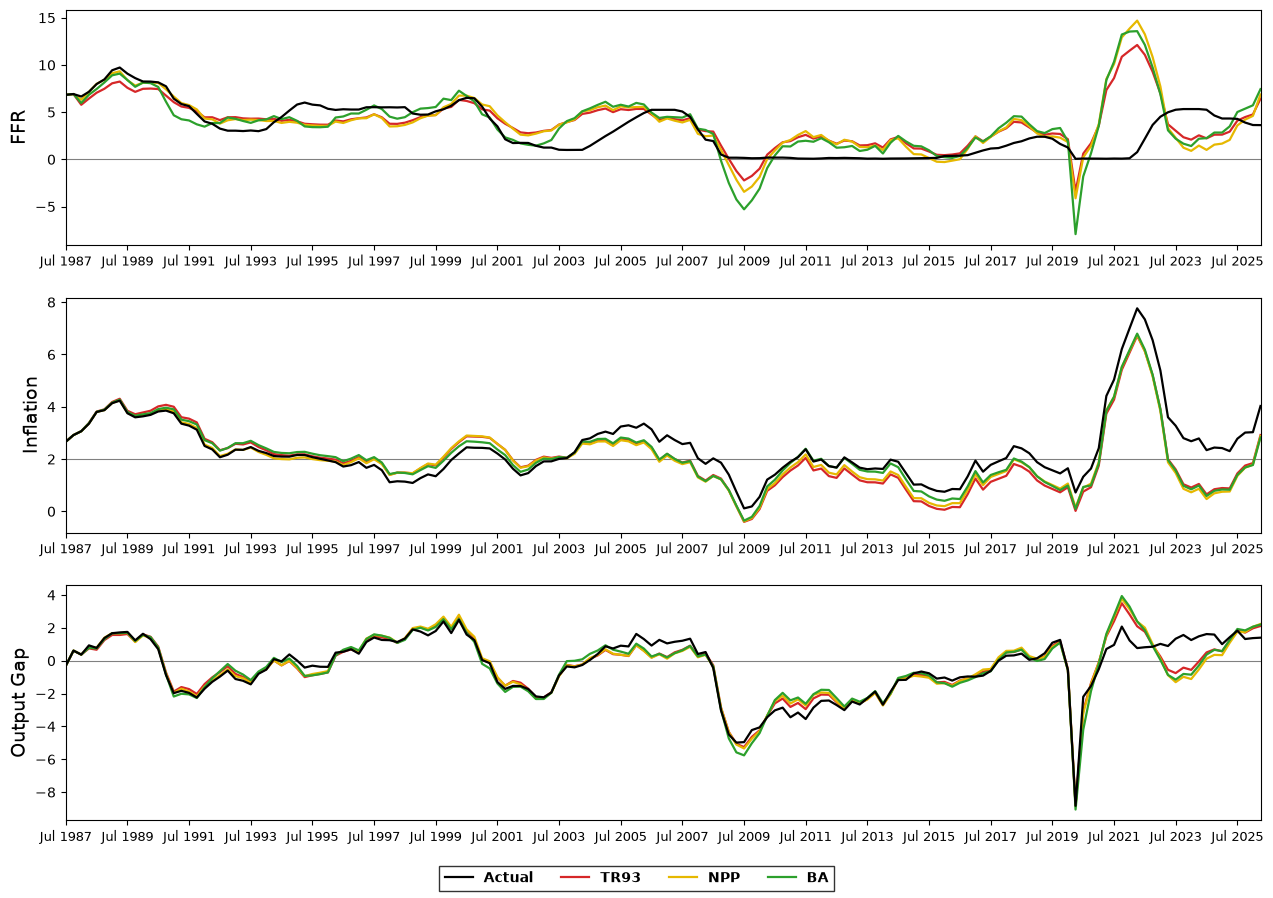

In [8]:
COLORS: dict[str, str] = {"Actual": "black", **{r.name: r.color for r in RULES}}
PANELS: tuple[tuple[str, str, float], ...] = (
    ("ffr", "FFR", 0.0),
    ("pi", "Inflation", PI_STAR),
    ("y", "Output Gap", 0.0),
)

index = df.index
xticks = pd.date_range(index[0], index[-1], freq=pd.DateOffset(years=2))

fig, axes = plt.subplots(len(PANELS), 1, figsize=(13, 9))
for ax, (col, label, ref) in zip(axes, PANELS):
    ax.axhline(ref, color="grey", lw=0.8)
    for name, path in paths.items():
        ax.plot(index, path[col], color=COLORS[name], lw=1.6, label=name, zorder=3 if name == "Actual" else 2)
    ax.set_ylabel(label, fontsize=14)
    ax.set_xlim(index[0], index[-1])
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis="x", labelsize=9)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", ncol=len(labels), frameon=True, fancybox=False,
    edgecolor="black", prop={"weight": "bold", "size": 10},
)
fig.tight_layout(rect=(0, 0.04, 1, 1), h_pad=2.0)

FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "counterfactual_rules.png", dpi=FIG_DPI)
plt.show()

## 6. Target deviations and loss

$\Delta^2(\pi^*, \pi_t)$ and $\Delta^2(y^*, y_t)$ are mean squared deviations from $\pi^* = 2$ and $y^* = 0$; Loss $= 0.5\,\Delta^2(\pi^*, \pi_t) + 0.5\,\Delta^2(y^*, y_t)$. The `paper` block is Table 5 of the paper (SVAR economy, 1987Q3-2007Q2).

In [9]:
PAPER_LOSS = pd.DataFrame(
    {"d2 pi": [0.84, 0.91, 0.83, 1.04], "d2 y": [2.98, 3.01, 3.03, 3.37], "loss": [1.91, 1.96, 1.93, 2.21]},
    index=["Actual", "TR93", "NPP", "BA"],
)


def loss_table(window: slice) -> pd.DataFrame:
    """Mean squared target deviations and loss per policy over ``window``."""
    rows = {}
    for name, path in paths.items():
        p = path.loc[window]
        d2_pi = float(((p["pi"] - PI_STAR) ** 2).mean())
        d2_y = float((p["y"] ** 2).mean())
        rows[name] = {"d2 pi": d2_pi, "d2 y": d2_y, "loss": 0.5 * d2_pi + 0.5 * d2_y}
    return pd.DataFrame.from_dict(rows, orient="index")


losses = pd.concat(
    {
        "1987Q3-2007Q2": loss_table(slice(SAMPLE_START, EST_END)),
        "full sample": loss_table(slice(None)),
        "paper": PAPER_LOSS,
    },
    axis=1,
).round(2)

pd.concat(paths, axis=1).round(4).to_csv(FIG_DIR / "counterfactual_rules.csv", index_label="date")
losses

1987Q3-2007Q2             full sample             paper            
               d2 pi  d2 y  loss       d2 pi  d2 y  loss d2 pi  d2 y  loss
Actual          0.85  1.62  1.24        1.67  3.31  2.49  0.84  2.98  1.91
TR93            0.83  1.49  1.16        1.53  3.27  2.40  0.91  3.01  1.96
NPP             0.73  1.63  1.18        1.44  3.41  2.43  0.83  3.03  1.93
BA              0.78  1.63  1.21        1.41  3.56  2.48  1.04  3.37  2.21